In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    mean_squared_error, mean_absolute_error, r2_score
)
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

np.random.seed(42)
sns.set_style("whitegrid")

In [3]:
X, y = make_classification(n_samples=1000, n_features=20, n_informative=10, n_redundant=5, random_state=42)

model = LogisticRegression(max_iter=1000)

kfold = KFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=kfold, scoring="accuracy")

print("Accuracy for each of the 5 folds:", np.round(cv_scores, 3))
print(f"Mean accuracy: {cv_scores.mean():.3f}  (+/- {cv_scores.std():.3f})")

Accuracy for each of the 5 folds: [0.79 0.8  0.89 0.9  0.83 0.82 0.88 0.85 0.79 0.82]
Mean accuracy: 0.837  (+/- 0.039)


In [4]:
from sklearn.metrics import precision_score, recall_score

y_true = [1] * 100 + [0] * 900
y_pred = (
    [1] * 80 + [0] * 20 +
    [1] * 40 + [0] * 860
)

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.6666666666666666
Recall: 0.8


In [5]:
X_reg, y_reg = make_regression(n_samples=300, n_features=3, noise=50, random_state=42)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

reg_model = LinearRegression()
reg_model.fit(Xr_train, yr_train)
yr_pred = reg_model.predict(Xr_test)

mse = mean_squared_error(yr_test, yr_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(yr_test, yr_pred)
r2 = r2_score(yr_test, yr_pred)

print(f"MSE  : {mse:.2f}   -- average squared error (penalizes big misses)")
print(f"RMSE : {rmse:.2f}   -- same units as the target, easier to interpret")
print(f"MAE  : {mae:.2f}   -- average absolute error, less sensitive to outliers")
print(f"R^2  : {r2:.3f}   -- fraction of variance explained (1.0 = perfect)")


MSE  : 1897.94   -- average squared error (penalizes big misses)
RMSE : 43.57   -- same units as the target, easier to interpret
MAE  : 35.08   -- average absolute error, less sensitive to outliers
R^2  : 0.892   -- fraction of variance explained (1.0 = perfect)


Class counts: [974  26]
Class 1 makes up 2.6% of the data


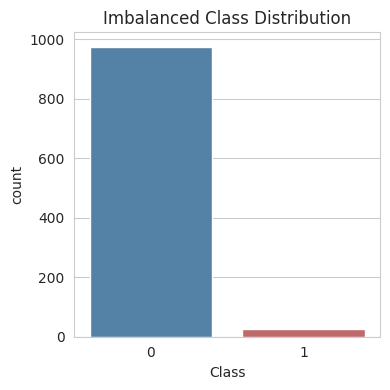

In [6]:
X_imb, y_imb = make_classification(
    n_samples=1000, n_features=6, n_informative=4,
    weights=[0.98, 0.02],
    random_state=42
)

print("Class counts:", np.bincount(y_imb))
print(f"Class 1 makes up {np.bincount(y_imb)[1] / len(y_imb) * 100:.1f}% of the data")

plt.figure(figsize=(4, 4))
sns.countplot(x=y_imb, hue=y_imb, palette=["steelblue", "indianred"], legend=False)
plt.title("Imbalanced Class Distribution")
plt.xlabel("Class")
plt.tight_layout()
plt.show()
